# 02d: The Otsu Threshold in Buffit

**Buffit** classifies each elution frame as *buffer* or *protein* and fits the 2D baseline only to the buffer frames.
The threshold that separates the two classes is determined automatically by **Otsu's method** (Otsu 1979).

This notebook explains:
1. The Otsu criterion — what it maximises and how it works
2. Why Otsu can include protein-tail frames in the buffer class for some datasets
3. Why this does not degrade baseline quality in practice


In [1]:
import os
import io
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from molass.DataObjects import SecSaxsData as SSD
from molass.Baseline.BuffitBaseline import _otsu_threshold

DATA_ROOT = r"C:\Users\takahashi\Dropbox\MOLASS\DATA\20260305"

with contextlib.redirect_stdout(io.StringIO()):
    ssd = SSD(os.path.join(DATA_ROOT, 'MY'))
    xr  = ssd.trimmed_copy().xr

M  = xr.M
jv = xr.jv
iv = xr.iv

elution_sum  = M.sum(axis=0)
elution_norm = elution_sum / elution_sum.max()

otsu_thr = _otsu_threshold(elution_norm)   # bins=100
fixed_thr = 0.10

print(f"Dataset: MY   frames={len(jv)}   q-rows={M.shape[0]}")
print(f"Otsu threshold  k* = {otsu_thr:.4f}")
print(f"Fixed threshold    = {fixed_thr}")
print(f"Buffer frames (Otsu):  {(elution_norm < otsu_thr).sum()} / {len(jv)}")
print(f"Buffer frames (fixed): {(elution_norm < fixed_thr).sum()} / {len(jv)}")

zeros at the angular ends of error data have been replaced with the adjacent values.


Dataset: MY   frames=540   q-rows=973
Otsu threshold  k* = 0.4150
Fixed threshold    = 0.1
Buffer frames (Otsu):  475 / 540
Buffer frames (fixed): 428 / 540


## The Otsu criterion

Given a normalised intensity histogram with $L$ bins, Otsu's method finds the threshold $k^*$ that **maximises the between-class variance**:

$$
\sigma_B^2(k) = \omega_0(k)\,\omega_1(k)\,\bigl[\mu_1(k) - \mu_0(k)\bigr]^2
$$

where
- $\omega_0(k) = \sum_{i=0}^{k} p_i$ — fraction of pixels in class 0 (buffer, $\le k$)
- $\omega_1(k) = 1 - \omega_0(k)$ — fraction in class 1 (protein, $> k$)
- $\mu_0(k)$, $\mu_1(k)$ — class means

Maximising $\sigma_B^2$ is equivalent to minimising the **within-class variance** (the sum of variances inside each class).
The computation uses only the zeroth- and first-order cumulative moments of the histogram, so it is fast and parameter-free.

$$
k^* = \arg\max_k \sigma_B^2(k)
$$

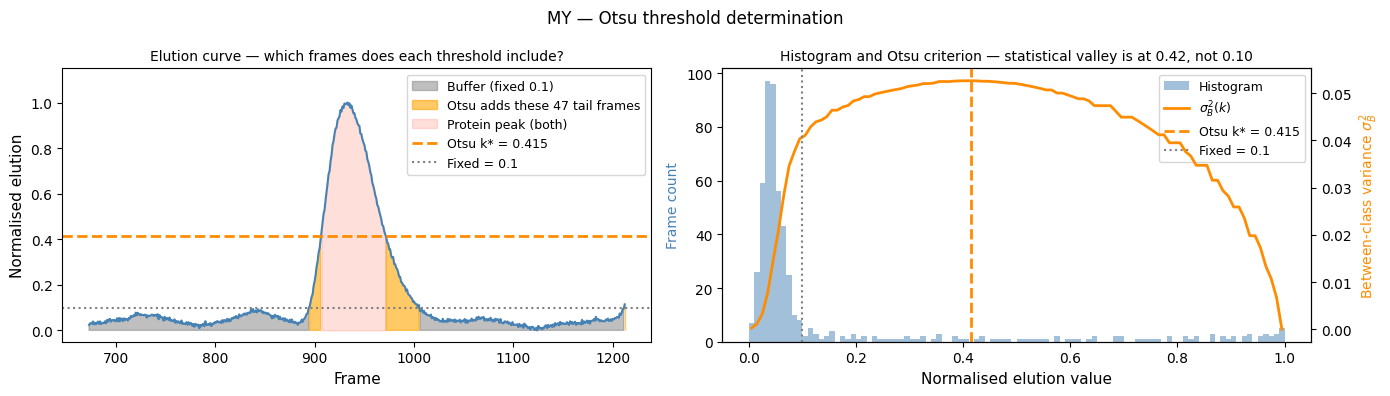

Saved: 02d_fig1_otsu_criterion.png


In [2]:
# Reconstruct sigma_B^2 curve for visualisation (same bins=100 as the library)
nbins = 100
counts, edges = np.histogram(elution_norm, bins=nbins, range=(0.0, 1.0))
bin_centers = (edges[:-1] + edges[1:]) / 2
p = counts / counts.sum()
omega  = np.cumsum(p)
mu_cum = np.cumsum(p * bin_centers)
mu_T   = mu_cum[-1]
omega1 = 1.0 - omega
with np.errstate(divide='ignore', invalid='ignore'):
    sigma_B2 = np.where(
        (omega > 0) & (omega1 > 0),
        omega * omega1 * (mu_cum / omega - (mu_T - mu_cum) / omega1) ** 2,
        0.0
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('MY — Otsu threshold determination', fontsize=12)

# Left: elution with Otsu and fixed threshold coloured
ax = axes[0]
orange_mask = (elution_norm >= fixed_thr) & (elution_norm < otsu_thr)
ax.plot(jv, elution_norm, color='steelblue', lw=1.5)
ax.fill_between(jv, 0, elution_norm, where=elution_norm < fixed_thr,
                alpha=0.5, color='gray',   label=f'Buffer (fixed {fixed_thr})')
ax.fill_between(jv, 0, elution_norm, where=orange_mask,
                alpha=0.6, color='orange', label=f'Otsu adds these {orange_mask.sum()} tail frames')
ax.fill_between(jv, 0, elution_norm, where=elution_norm >= otsu_thr,
                alpha=0.2, color='tomato', label='Protein peak (both)')
ax.axhline(otsu_thr,  color='darkorange', lw=2,   linestyle='--', label=f'Otsu k* = {otsu_thr:.3f}')
ax.axhline(fixed_thr, color='gray',       lw=1.5, linestyle=':',  label=f'Fixed = {fixed_thr}')
ax.set_xlabel('Frame', fontsize=11)
ax.set_ylabel('Normalised elution', fontsize=11)
ax.set_ylim(-0.05, 1.15)
ax.legend(fontsize=9)
ax.set_title('Elution curve — which frames does each threshold include?', fontsize=10)

# Right: histogram + sigma_B^2
ax_h = axes[1]
ax_v = ax_h.twinx()
ax_h.bar(bin_centers, counts, width=1/nbins, color='steelblue', alpha=0.5, label='Histogram')
ax_v.plot(bin_centers, sigma_B2, color='darkorange', lw=2, label='$\\sigma_B^2(k)$')
ax_v.axvline(otsu_thr,  color='darkorange', lw=2,   linestyle='--', label=f'Otsu k* = {otsu_thr:.3f}')
ax_v.axvline(fixed_thr, color='gray',       lw=1.5, linestyle=':',  label=f'Fixed = {fixed_thr}')
ax_h.set_xlabel('Normalised elution value', fontsize=11)
ax_h.set_ylabel('Frame count', color='steelblue',  fontsize=10)
ax_v.set_ylabel('Between-class variance $\\sigma_B^2$', color='darkorange', fontsize=10)
ax_h.set_title('Histogram and Otsu criterion — statistical valley is at 0.42, not 0.10', fontsize=10)
lines1, labels1 = ax_h.get_legend_handles_labels()
lines2, labels2 = ax_v.get_legend_handles_labels()
ax_h.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

plt.tight_layout()
plt.savefig('02d_fig1_otsu_criterion.png', dpi=150)
plt.show()
print('Saved: 02d_fig1_otsu_criterion.png')

## Why Otsu includes protein-tail frames for MY

The elution histogram of MY is **bimodal**:
- A large peak near 0 (buffer frames, elution ≈ 0.01–0.08)
- A broad shoulder/peak near 1 (protein peak frames)

Otsu places $k^*$ at the **statistical valley between the two modes**, which for MY is around 0.41.
However, the rising and falling **tails** of the protein peak (elution ≈ 0.10–0.41) are sparse — they lie between the two modes — so Otsu assigns them to the buffer class.

These are physically protein-containing frames, not true buffer. Including them in the baseline fit would force the baseline to partially follow the protein signal in those regions.

Frames in Otsu buffer zone but elution_norm > 0.1: 47
  median    = 0.209
  90th pct  = 0.357
  max       = 0.409

Fixed threshold (0.1) excludes all 47 tail frames.
Otsu k*=0.415 includes them — statistically optimal but physically liberal.


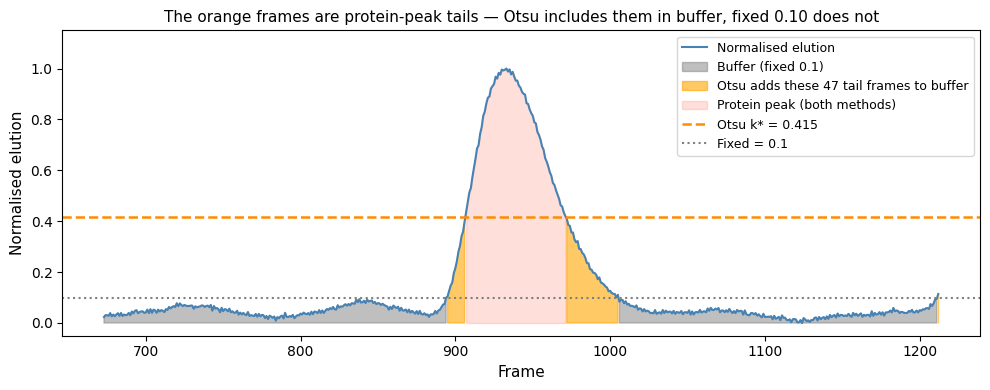

Saved: 02d_fig2_tail_frames.png


In [3]:
# Quantify the 'orange zone': Otsu buffer frames with elution_norm > fixed_thr
orange_vals = elution_norm[orange_mask]

print(f"Frames in Otsu buffer zone but elution_norm > {fixed_thr}: {orange_mask.sum()}")
print(f"  median    = {np.median(orange_vals):.3f}")
print(f"  90th pct  = {np.percentile(orange_vals, 90):.3f}")
print(f"  max       = {orange_vals.max():.3f}")
print()
print(f"Fixed threshold ({fixed_thr}) excludes all {orange_mask.sum()} tail frames.")
print(f"Otsu k*={otsu_thr:.3f} includes them — statistically optimal but physically liberal.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(jv, elution_norm, color='steelblue', lw=1.5, label='Normalised elution')
ax.fill_between(jv, 0, elution_norm, where=elution_norm < fixed_thr,
                alpha=0.5, color='gray',   label=f'Buffer (fixed {fixed_thr})')
ax.fill_between(jv, 0, elution_norm, where=orange_mask,
                alpha=0.6, color='orange', label=f'Otsu adds these {orange_mask.sum()} tail frames to buffer')
ax.fill_between(jv, 0, elution_norm, where=elution_norm >= otsu_thr,
                alpha=0.2, color='tomato', label='Protein peak (both methods)')
ax.axhline(otsu_thr,  color='darkorange', lw=1.8, linestyle='--', label=f'Otsu k* = {otsu_thr:.3f}')
ax.axhline(fixed_thr, color='gray',       lw=1.5, linestyle=':',  label=f'Fixed = {fixed_thr}')
ax.set_xlabel('Frame', fontsize=11)
ax.set_ylabel('Normalised elution', fontsize=11)
ax.set_title('The orange frames are protein-peak tails — Otsu includes them in buffer, fixed 0.10 does not', fontsize=11)
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.15)
plt.tight_layout()
plt.savefig('02d_fig2_tail_frames.png', dpi=150)
plt.show()
print('Saved: 02d_fig2_tail_frames.png')

## From buffer mask to baseline: the polyfit step

Once the buffer mask is established, Buffit computes the baseline **per q-row** by a simple linear fit anchored on the buffer frames only:

```python
slope, intercept = np.polyfit(x[buffer_mask], y[buffer_mask], 1)
baseline = x * slope + intercept          # extrapolated across all frames
```

The key points:

- The fit uses only the ~475 buffer frames (Otsu) out of 540, ignoring the protein-peak frames.
- The result is a straight line `a·x + b` that is then **extrapolated** under the protein peak.
- For high-q rows the intensity profile is nearly flat (pure noise), so the slope is close to zero and the fit is stable regardless of which frames are included.
- For low-q rows the protein signal is large, but those peak frames (`elution_norm ≥ k*`) are excluded and the fit is anchored on true buffer frames only.

**Why do the ~47 orange tail frames not hurt?**
Their elution_norm lies in 0.10–0.41, so the scattering intensity at those frames is a small fraction of the peak intensity.
A linear fit is not very sensitive to points with small residuals, so these frames contribute little leverage to the slope and intercept.
The result is that the baseline estimated with Otsu (k*≈0.41) and with the conservative fixed threshold (0.10) are nearly identical in practice — as reflected in the `positive_ratio` of 0.496 (Otsu) seen in `02b_buffit_explanation.ipynb`.


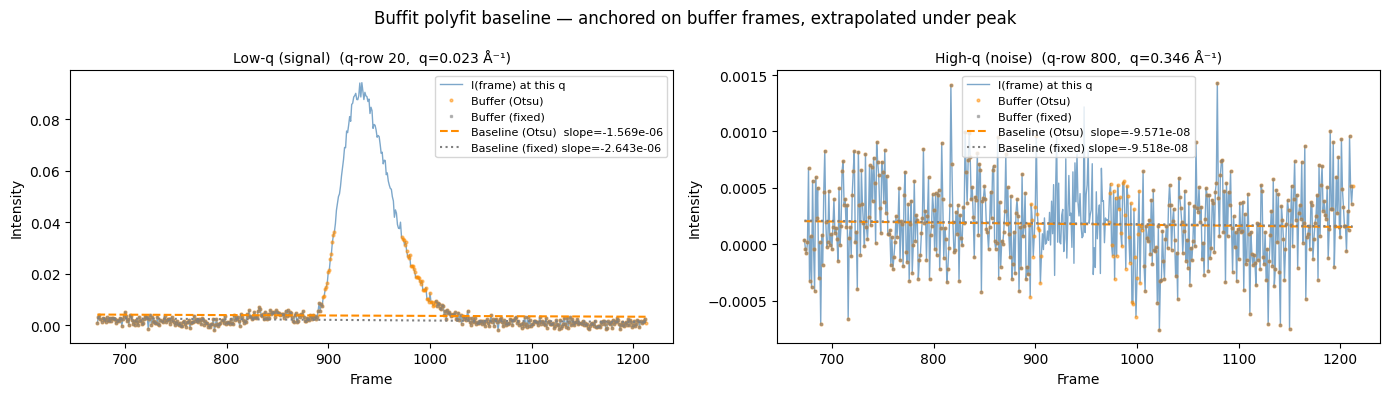

Saved: 02d_fig3_polyfit_rows.png


In [4]:
# Fig 3: polyfit baseline for two q-rows — one low-q (signal), one high-q (noise)
buf_mask_otsu  = elution_norm < otsu_thr
buf_mask_fixed = elution_norm < fixed_thr

x = jv.astype(float)
q_lo_idx = 20    # low-q row: strong signal
q_hi_idx = 800   # high-q row: near-noise

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Buffit polyfit baseline — anchored on buffer frames, extrapolated under peak', fontsize=12)

for ax, qi, label in zip(axes, [q_lo_idx, q_hi_idx], ['Low-q (signal)', 'High-q (noise)']):
    y = M[qi, :]
    s_o, i_o = np.polyfit(x[buf_mask_otsu],  y[buf_mask_otsu],  1)
    s_f, i_f = np.polyfit(x[buf_mask_fixed], y[buf_mask_fixed], 1)
    bl_otsu  = x * s_o + i_o
    bl_fixed = x * s_f + i_f

    ax.plot(x, y, color='steelblue', lw=1, alpha=0.7, label='I(frame) at this q')
    ax.plot(x[buf_mask_otsu],  y[buf_mask_otsu],  'o', ms=2, color='darkorange', alpha=0.5, label='Buffer (Otsu)')
    ax.plot(x[buf_mask_fixed], y[buf_mask_fixed], 's', ms=2, color='gray',       alpha=0.5, label='Buffer (fixed)')
    ax.plot(x, bl_otsu,  '--', color='darkorange', lw=1.5, label=f'Baseline (Otsu)  slope={s_o:.3e}')
    ax.plot(x, bl_fixed, ':',  color='gray',       lw=1.5, label=f'Baseline (fixed) slope={s_f:.3e}')
    ax.set_title(f'{label}  (q-row {qi},  q={iv[qi]:.3f} Å⁻¹)', fontsize=10)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Intensity')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('02d_fig3_polyfit_rows.png', dpi=150)
plt.show()
print('Saved: 02d_fig3_polyfit_rows.png')


## Summary

| Threshold | Buffer frames | Tail frames included | Physically correct? |
|-----------|:---:|:---:|:---:|
| Otsu k* ≈ 0.41 | ~475 / 540 | yes (~47 tail frames) | no — protein tails |
| Fixed 0.10 | ~428 / 540 | no | yes — true buffer only |

**Otsu is statistically optimal** (maximises separation between histogram modes) and **works well in practice**, even for MY where it includes ~47 protein-tail frames in the buffer class.

The apparent paradox — including physically impure frames — does not degrade baseline quality, because those tail frames have very low intensity (elution_norm ≈ 0.10–0.41) and the linear baseline fit is robust to the small signal they carry. This is confirmed directly in `02b_buffit_explanation.ipynb`: Buffit achieves a `positive_ratio` of 0.496 for MY (effectively ideal), while LPM with a physically motivated adaptive `p_final` gives only 0.854.

The Otsu threshold is the library default and is recommended for general use.
